# BrushCue Example: Liquify

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/liquify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/liquify

In [ ]:
!pip install brushcue

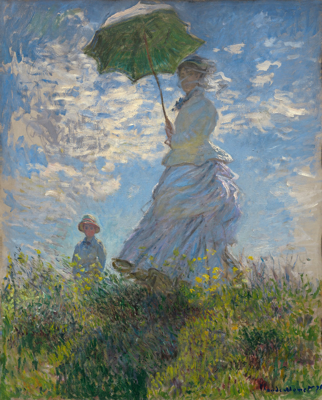

In [1]:
import brushcue
from PIL import Image
import io

input_image_1 = brushcue.composition_monet_women_with_parasol() # insert your own image here
string_constant_2 = brushcue.string_constant("\nlet freq = frequency;\nlet amp = amplitude;\nlet offset = sin(f32(position.x) * freq + sin(f32(position.y) * freq)) * amp;\nlet offsetY = cos(f32(position.y) * freq + sin(f32(position.x) * freq)) * amp;\nlet new_pos = vec2<f32>(vec2<f32>(position) + vec2(offset, offsetY));\nlet dims = vec2<f32>(textureDimensions(input_texture, 0));\nlet clamped_pos = vec2<u32>(max(vec2(0.0), min(new_pos, dims - vec2(1.0))));\nlet displaced = textureLoad(input_texture, clamped_pos, 0);\nreturn displaced;")
string_constant_3 = brushcue.string_constant("\n// no helpers needed")
composition_color_profile_4 = brushcue.composition_color_profile(input_image_1)
composition_color_profile_5 = brushcue.composition_color_profile(input_image_1)
bool_constant_6 = brushcue.bool_constant(True)
string_constant_7 = brushcue.string_constant("amplitude")
dictionary_create_8 = brushcue.dictionary_create()
string_constant_9 = brushcue.string_constant("frequency")
float_constant_10 = brushcue.float_constant(0.013000000268220901)
float_constant_11 = brushcue.float_constant(1000.0)
float_constant_12 = brushcue.float_constant(5.0)
composition_size_13 = brushcue.composition_size(input_image_1)
frequency_14 = brushcue.float_passthrough(float_constant_10)
amplitude_15 = brushcue.float_passthrough(float_constant_12)
vector_2_int_get_y_16 = brushcue.vector2i_y(composition_size_13)
float_add_to_dictionary_17 = brushcue.float_add_to_dictionary(dictionary_create_8, string_constant_9, frequency_14)
float_divide_18 = brushcue.float_divide(amplitude_15, float_constant_11)
int_to_float_19 = brushcue.int_to_float(vector_2_int_get_y_16)
float_multiply_20 = brushcue.float_multiply(float_divide_18, int_to_float_19)
float_add_to_dictionary_21 = brushcue.float_add_to_dictionary(float_add_to_dictionary_17, string_constant_7, float_multiply_20)
liquify_shader_22 = brushcue.composition_custom_transformer_shader(input_image_1, string_constant_2, string_constant_3, composition_color_profile_4, composition_color_profile_5, float_add_to_dictionary_21, bool_constant_6)

ctx = brushcue.Context()
result = liquify_shader_22.execute(ctx)
composition = result.as_composition()
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400)) # remove this line for full resolution
img
